In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Load your generated master dataset
df = pd.read_csv("../data/uav_fault_dataset.csv")

# Isolate just our single target flight file
# flight_df = df[df['bag'] == 'carbonZ_2018-07-18-12-10-11.bag'].copy()#healty 
flight_df = df[df['bag'] == 'carbonZ_2018-09-11-11-56-30.bag'].copy()#fault


print(f"=== ANALYSIS FOR FLIGHT ===")
print(f"Total time steps recorded at 20Hz: {len(flight_df):,}")

# Reset index to count steps from 0 to the end of the flight
flight_df.reset_index(drop=True, inplace=True)

# 1. Identify which anomaly was injected into this flight
fault_cols = ['engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault']
active_faults = []

for col in fault_cols:
    if flight_df[col].max() > 0:
        active_faults.append(col)
        # Find the exact row index step where the failure begins
        fail_start_idx = flight_df[flight_df[col] > 0].index[0]
        print(f"-> Detected Injected Fault: {col} (Starts at row index: {fail_start_idx})")

if not active_faults:
    print("-> This is an entirely healthy baseline flight file.")

# 2. Print a quick sensory snapshot before vs after the anomaly
if active_faults:
    target_fault = active_faults[0]
    healthy_phase = flight_df[flight_df[target_fault] == 0]
    faulty_phase = flight_df[flight_df[target_fault] > 0]
    
    print("\n=== SYSTEM RESPONSE BREAKDOWN ===")
    print("--- Healthy Phase (Mean Values) ---")
    print(f"Roll Command:  {healthy_phase['roll_cmd'].mean():.2f}° | Real Roll:  {healthy_phase['roll_meas'].mean():.2f}°")
    print(f"Pitch Command: {healthy_phase['pitch_cmd'].mean():.2f}° | Real Pitch: {healthy_phase['pitch_meas'].mean():.2f}°")
    
    print("\n--- Faulty Phase (Mean Values) ---")
    print(f"Roll Command:  {faulty_phase['roll_cmd'].mean():.2f}° | Real Roll:  {faulty_phase['roll_meas'].mean():.2f}°")
    print(f"Pitch Command: {flight_df['pitch_cmd'].mean():.2f}° | Real Pitch: {flight_df['pitch_meas'].mean():.2f}°")


=== ANALYSIS FOR FLIGHT ===
Total time steps recorded at 20Hz: 3,603
-> Detected Injected Fault: engine_fault (Starts at row index: 3201)

=== SYSTEM RESPONSE BREAKDOWN ===
--- Healthy Phase (Mean Values) ---
Roll Command:  12.66° | Real Roll:  12.29°
Pitch Command: -3.39° | Real Pitch: -2.49°

--- Faulty Phase (Mean Values) ---
Roll Command:  12.92° | Real Roll:  9.56°
Pitch Command: -1.84° | Real Pitch: -2.20°


In [11]:
df.columns

Index(['bag', 'timestamp_ns', 'roll_cmd', 'roll_meas', 'roll_error',
       'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas',
       'yaw_error', 'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z',
       'engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault',
       'ground_speed'],
      dtype='object')

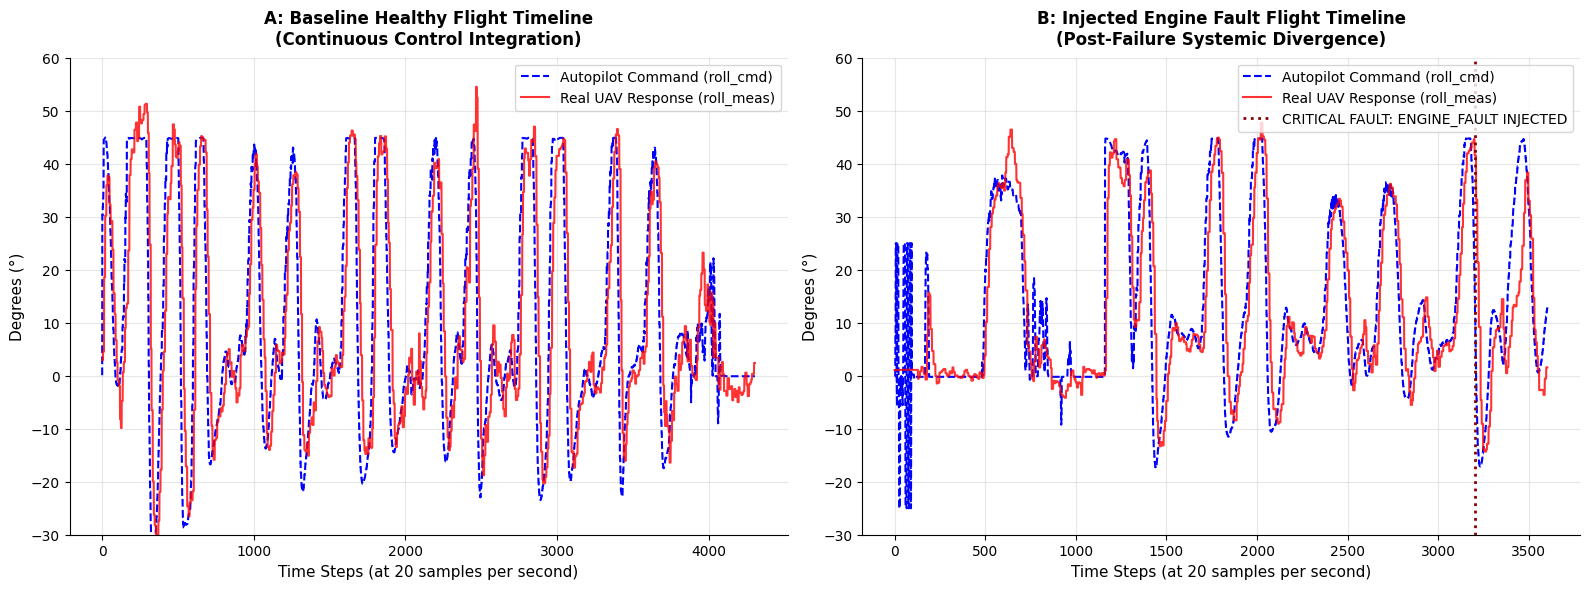

Success! Comparative slide graphic generated and saved as: healthy_vs_fault_comparison.png


In [8]:
# Set up a professional academic styling canvas
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Initialize a side-by-side 2-panel figure layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------------------------------------------
# PANEL 1: HEALTHY FLIGHT (carbonZ_2018-07-18-12-10-11.bag)
# -----------------------------------------------------------------
healthy_df = df[df['bag'] == 'carbonZ_2018-07-18-12-10-11.bag'].copy().reset_index(drop=True)
time_axis_h = healthy_df.index

# Plot commands vs measurements
ax1.plot(time_axis_h, healthy_df['roll_cmd'], label='Autopilot Command (roll_cmd)', color='blue', linestyle='--')
ax1.plot(time_axis_h, healthy_df['roll_meas'], label='Real UAV Response (roll_meas)', color='red', alpha=0.8)

ax1.set_title('A: Baseline Healthy Flight Timeline\n(Continuous Control Integration)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Time Steps (at 20 samples per second)', fontsize=11)
ax1.set_ylabel('Degrees (°)', fontsize=11)
ax1.set_ylim(-30, 60)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Remove top/right spines for cleaner academic presentation look
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)


# -----------------------------------------------------------------
# PANEL 2: FAULT FLIGHT (carbonZ_2018-09-11-11-56-30.bag)
# -----------------------------------------------------------------
fault_df = df[df['bag'] == 'carbonZ_2018-09-11-11-56-30.bag'].copy().reset_index(drop=True)
time_axis_f = fault_df.index

# Plot commands vs measurements
ax2.plot(time_axis_f, fault_df['roll_cmd'], label='Autopilot Command (roll_cmd)', color='blue', linestyle='--')
ax2.plot(time_axis_f, fault_df['roll_meas'], label='Real UAV Response (roll_meas)', color='red', alpha=0.8)

# Find the exact first row step index where any fault triggers
for col in ['engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault']:
    if fault_df[col].max() > 0:
        fail_idx = fault_df[fault_df[col] > 0].index[0]
        ax2.axvline(x=fail_idx, color='darkred', linestyle=':', linewidth=2, 
                    label=f'CRITICAL FAULT: {col.upper()} INJECTED')

ax2.set_title('B: Injected Engine Fault Flight Timeline\n(Post-Failure Systemic Divergence)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Time Steps (at 20 samples per second)', fontsize=11)
ax2.set_ylabel('Degrees (°)', fontsize=11)
ax2.set_ylim(-30, 60)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Adjust layout rendering smoothly and save as output image
plt.tight_layout()
output_filename = "healthy_vs_fault_comparison.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Comparative slide graphic generated and saved as: {output_filename}")


In [1]:
df.describe()

NameError: name 'df' is not defined